# Diagnostiquer un modèle : overfitting, biais-variance et régularisation

**Jour 2 — chapitre 01 : Qu'est-ce qu'un bon modèle ? (les pièges du machine learning)**

## Mise en situation

Un concessionnaire veut estimer la consommation d'un véhicule à partir de sa puissance.
On va entraîner une régression linéaire, la laisser devenir de plus en plus complexe, et
regarder ce qui se passe. C'est la démonstration des trois pièges vus en cours :
l'**underfitting**, l'**overfitting**, et la **régularisation** qui corrige le second.

Le déroulé tient en quatre temps :

1. Entraîner un premier modèle et mesurer son erreur, sur l'entraînement **et** sur le test.
2. Donner plus de liberté au modèle, et voir les deux erreurs partir dans des directions
   opposées.
3. Lire le diagnostic dans un tableau : c'est l'écart entre les deux erreurs.
4. Corriger, avec Ridge et Lasso.

Un seul algorithme dans tout le notebook : la **régression linéaire** du jour 1.

### Les données

Le jeu de données `mpg` livré avec seaborn : 392 voitures américaines des années 1970-1980.

| Colonne | Signification |
|---|---|
| `horsepower` | puissance du moteur, en chevaux (la variable explicative) |
| `mpg` | *miles per gallon*, la distance parcourue avec un gallon d'essence (la cible) |

Attention au sens de la cible : `mpg` **élevé** = voiture **sobre**. Une grosse cylindrée
tourne autour de 12, une petite citadine autour de 35.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

voitures = sns.load_dataset("mpg").dropna(subset=["horsepower", "mpg"])

# Le concessionnaire n'a releve que 100 vehicules. Peu de donnees pour un modele a qui on
# va donner beaucoup de liberte : c'est la situation ou l'overfitting apparait.
echantillon = voitures.sample(n=100, random_state=42)

X = echantillon[["horsepower"]]
y = echantillon["mpg"]

print("Véhicules retenus :", len(echantillon))
print("Puissance : de", int(X["horsepower"].min()), "à", int(X["horsepower"].max()), "chevaux")

echantillon[["name", "horsepower", "mpg"]].head()

Véhicules retenus : 100
Puissance : de 46 à 225 chevaux


,name,horsepower,mpg
79,renault 12 (sw),69.0,26.0
276,saab 99gle,115.0,21.6
248,honda civic cvcc,60.0,36.1
56,plymouth cricket,70.0,26.0
393,ford mustang gl,86.0,27.0


## Étape 1 — Un premier modèle, et deux erreurs à comparer

**Question de réflexion :** pourquoi mesurer l'erreur sur les données d'entraînement ne
suffit-il pas à juger un modèle ?

On sépare les véhicules en deux paquets : 60 pour **entraîner** le modèle, 40 mis de côté
pour le **tester**. Le modèle ne verra jamais ces 40 véhicules pendant son entraînement :
c'est le seul moyen de savoir s'il généralise ou s'il récite.

L'erreur se mesure avec le **RMSE** (racine de l'erreur quadratique moyenne), vu dans les
slides précédentes. Il s'exprime dans l'unité de la cible : un RMSE de 4 signifie qu'on se
trompe en moyenne d'environ 4 mpg. Plus il est bas, meilleur est le modèle.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
print("Entraînement :", len(X_train), "véhicules  |  Test :", len(X_test), "véhicules")

droite = LinearRegression()
droite.fit(X_train, y_train)

rmse_train = root_mean_squared_error(y_train, droite.predict(X_train))
rmse_test = root_mean_squared_error(y_test, droite.predict(X_test))

print("RMSE sur l'entraînement :", round(rmse_train, 2), "mpg")
print("RMSE sur le test        :", round(rmse_test, 2), "mpg")

Entraînement : 60 véhicules  |  Test : 40 véhicules
RMSE sur l'entraînement : 4.11 mpg
RMSE sur le test        : 5.13 mpg


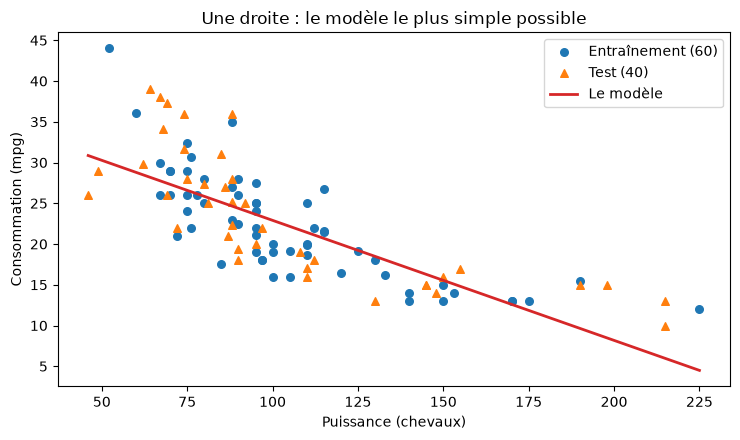

In [3]:
import matplotlib.pyplot as plt

# Une grille de puissances, pour tracer la courbe du modele sur tout l'intervalle.
grille = pd.DataFrame({"horsepower": np.linspace(X["horsepower"].min(), X["horsepower"].max(), 300)})

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(X_train["horsepower"], y_train, s=30, label="Entraînement (60)")
ax.scatter(X_test["horsepower"], y_test, s=30, marker="^", color="tab:orange", label="Test (40)")
ax.plot(grille["horsepower"], droite.predict(grille), color="tab:red", linewidth=2, label="Le modèle")
ax.set_xlabel("Puissance (chevaux)")
ax.set_ylabel("Consommation (mpg)")
ax.set_title("Une droite : le modèle le plus simple possible")
ax.legend()
plt.tight_layout()
plt.show()

**Ce qu'on observe** : la droite descend bien — plus une voiture est puissante, moins elle
est sobre — mais elle ne suit pas la forme du nuage. Les points partent vite vers le haut à
gauche et s'aplatissent à droite, là où la droite, elle, continue de descendre tout droit.
Prolongée, elle finirait par annoncer une consommation négative.

Résultat : 4,11 mpg d'erreur sur l'entraînement et 5,13 sur le test. Deux erreurs assez
proches, mais **toutes les deux élevées**. Le modèle ne mémorise rien, il est simplement
trop simple pour la question posée : c'est l'**underfitting** (sous-apprentissage), la
signature d'un **biais élevé**.

Le premier réflexe est donc de lui donner plus de liberté.

## Étape 2 — Donner plus de liberté au modèle

**Question de réflexion :** une régression linéaire trace une droite. Comment lui faire
tracer une courbe, sans changer d'algorithme ?

En lui donnant plus de colonnes. Si, à côté de `horsepower`, on ajoute une colonne
`horsepower²`, le modèle cherche toujours des coefficients pour une somme pondérée — c'est
toujours une régression linéaire — mais le résultat dessine une parabole. Avec
`horsepower³`, une courbe qui peut s'infléchir deux fois, et ainsi de suite.

Le **degré**, c'est-à-dire le nombre de puissances ajoutées, devient donc le bouton qui
règle la complexité du modèle.

Une précaution de calcul : on divise d'abord la puissance par 100. Sans cela, 130 à la
puissance 6 dépasse le millier de milliards, et les colonnes deviennent trop disparates
pour que le calcul reste fiable. Cela ne change pas le modèle, seulement l'échelle de ses
coefficients.

In [4]:
def colonnes_polynomiales(puissances, degre):
    """Construit les colonnes hp, hp^2, ... hp^degre (puissance divisee par 100)."""
    return pd.DataFrame(
        {f"hp^{k}": (puissances / 100) ** k for k in range(1, degre + 1)},
        index=puissances.index,
    )


# A quoi ressemblent les donnees vues par un modele de degre 3 :
colonnes_polynomiales(X_train["horsepower"], 3).head()

,hp^1,hp^2,hp^3
197,0.70,0.4900,0.343000
91,1.50,2.2500,3.375000
235,0.75,0.5625,0.421875
211,1.20,1.4400,1.728000
34,1.05,1.1025,1.157625


In [5]:
def entraine(degre):
    """Entraine une regression lineaire de ce degre et renvoie le modele et ses deux RMSE."""
    colonnes_train = colonnes_polynomiales(X_train["horsepower"], degre)
    colonnes_test = colonnes_polynomiales(X_test["horsepower"], degre)

    modele = LinearRegression()
    modele.fit(colonnes_train, y_train)

    return (modele,
            root_mean_squared_error(y_train, modele.predict(colonnes_train)),
            root_mean_squared_error(y_test, modele.predict(colonnes_test)))


for degre in [1, 2, 6]:
    modele, erreur_train, erreur_test = entraine(degre)
    print(f"Degré {degre} : RMSE entraînement {erreur_train:.2f} | RMSE test {erreur_test:.2f}")

Degré 1 : RMSE entraînement 4.11 | RMSE test 5.13
Degré 2 : RMSE entraînement 3.59 | RMSE test 4.60
Degré 6 : RMSE entraînement 3.28 | RMSE test 6.97


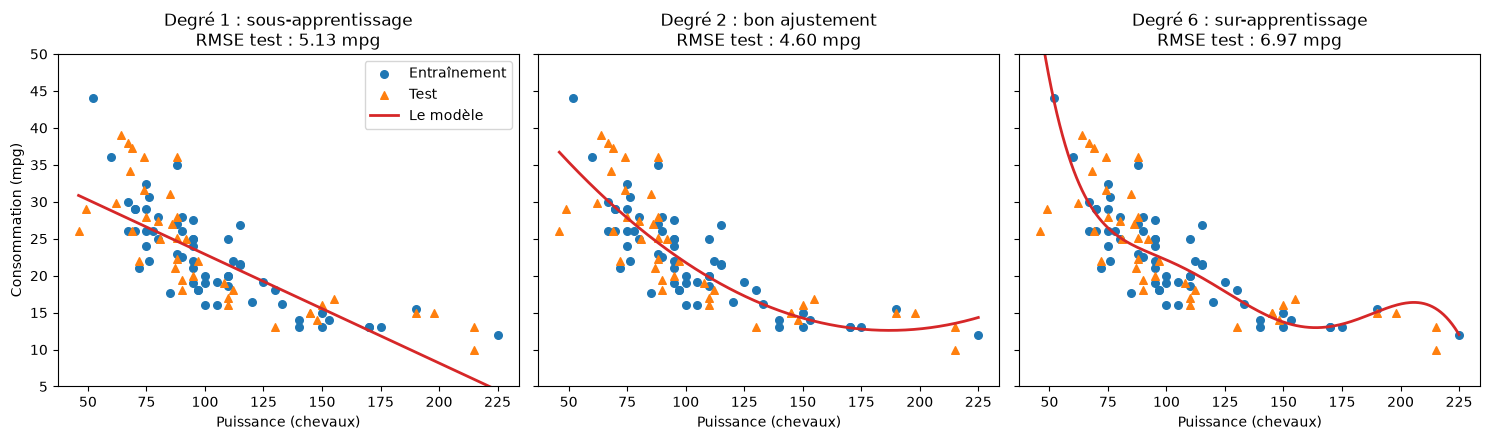

In [6]:
situations = {1: "Degré 1 : sous-apprentissage", 2: "Degré 2 : bon ajustement", 6: "Degré 6 : sur-apprentissage"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (degre, titre) in zip(axes, situations.items()):
    modele, _, erreur_test = entraine(degre)
    predictions = modele.predict(colonnes_polynomiales(grille["horsepower"], degre))

    ax.scatter(X_train["horsepower"], y_train, s=30, label="Entraînement")
    ax.scatter(X_test["horsepower"], y_test, s=30, marker="^", color="tab:orange", label="Test")
    ax.plot(grille["horsepower"], predictions, color="tab:red", linewidth=2, label="Le modèle")
    ax.set_title(f"{titre}\nRMSE test : {erreur_test:.2f} mpg")
    ax.set_xlabel("Puissance (chevaux)")

axes[0].set_ylabel("Consommation (mpg)")
axes[0].set_ylim(5, 50)
axes[0].legend()
plt.tight_layout()
plt.show()

**Ce qu'on observe** : les trois images de la slide, sur de vraies données.

- **Degré 1**, la droite : trop simple, elle rate la forme du nuage. Underfitting.
- **Degré 2**, la parabole : elle suit la tendance générale — chute rapide jusqu'à 100
  chevaux, puis stabilisation — sans chercher à passer par chaque point. C'est le meilleur
  des trois sur le test : 4,60 mpg.
- **Degré 6** : la courbe se tord pour aller chercher les points d'entraînement un par un,
  et plonge brutalement à droite, là où il n'y a presque aucun véhicule. Son erreur
  d'entraînement est la plus basse des trois, et son erreur de test la plus haute : 6,97
  mpg. C'est l'**overfitting** (sur-apprentissage) : le modèle **mémorise** au lieu de
  généraliser.

Retenez l'image : la courbe du degré 6 colle aux ronds bleus, et rate les triangles orange.

## Étape 3 — Le diagnostic chiffré

**Question de réflexion :** sur une seule variable, l'oeil suffit. Avec dix variables, plus
aucun graphique de ce type n'est possible. Quels nombres regarder à la place ?

On entraîne un modèle par degré, de 1 à 6, et on range les deux erreurs côte à côte.

In [7]:
diagnostic = []
for degre in range(1, 7):
    modele, erreur_train, erreur_test = entraine(degre)
    diagnostic.append({
        "degre": degre,
        "rmse_train": erreur_train,
        "rmse_test": erreur_test,
        "ecart": erreur_test - erreur_train,
        "coef_max": np.abs(modele.coef_).max(),
    })

diagnostic = pd.DataFrame(diagnostic)
diagnostic.round(2)

,degre,rmse_train,rmse_test,ecart,coef_max
0,1,4.11,5.13,1.02,14.73
1,2,3.59,4.60,1.01,45.35
2,3,3.53,4.79,1.26,85.82
3,4,3.46,5.48,2.01,254.17
4,5,3.28,6.87,3.58,1855.25
5,6,3.28,6.97,3.68,2620.11


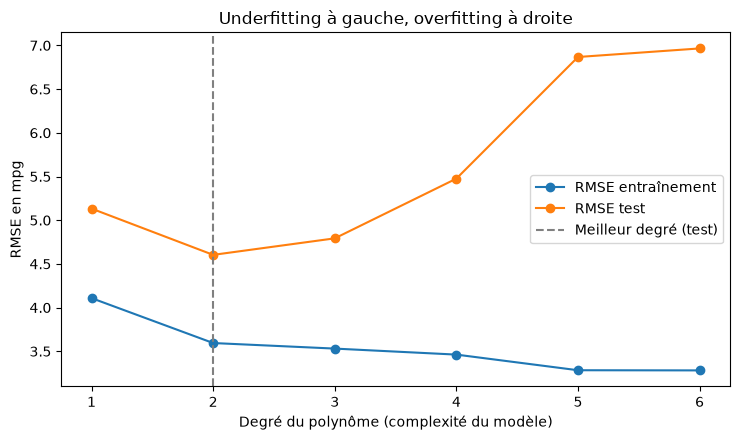

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(diagnostic["degre"], diagnostic["rmse_train"], marker="o", label="RMSE entraînement")
ax.plot(diagnostic["degre"], diagnostic["rmse_test"], marker="o", label="RMSE test")
ax.axvline(2, color="grey", linestyle="--", label="Meilleur degré (test)")
ax.set_xlabel("Degré du polynôme (complexité du modèle)")
ax.set_ylabel("RMSE en mpg")
ax.set_title("Underfitting à gauche, overfitting à droite")
ax.legend()
plt.tight_layout()
plt.show()

**Ce qu'on observe** : les deux courbes racontent toute l'histoire.

- L'erreur d'**entraînement** ne fait que descendre : 4,11 puis 3,59, jusqu'à 3,28. C'est
  normal, et c'est pour cela qu'elle ne prouve rien. Plus un modèle a de liberté, mieux il
  colle aux données qu'il a sous les yeux.
- L'erreur de **test** descend, atteint son minimum au degré 2 (4,60 mpg), puis remonte
  franchement : 5,48 au degré 4, 6,97 au degré 6.
- L'**écart** entre les deux erreurs part de 1,02 au degré 1 et atteint 3,68 au degré 6.

C'est le signal à retenir : **une erreur d'entraînement qui baisse pendant que l'erreur de
test remonte, c'est de l'overfitting**. Il se lit sur deux nombres, quel que soit le nombre
de variables.

Attention à ne pas confondre les deux pièges. Au degré 1, l'écart est le plus faible du
tableau, et le modèle est pourtant mauvais : deux erreurs proches mais toutes les deux
élevées, c'est de l'underfitting. Le bon modèle est au creux de la courbe de test, jamais là
où l'erreur d'entraînement est la plus basse. C'est le compromis **biais-variance**.

Regardez aussi la dernière colonne : le plus grand coefficient du modèle passe de 15 au
degré 1 à 2 620 au degré 6. C'est la clé de l'étape suivante.

## Étape 4 — Corriger : la régularisation

**Question de réflexion :** faut-il forcément revenir à un modèle plus simple, ou peut-on
garder le modèle complexe en l'empêchant de déraper ?

Pour passer par tous les points, le modèle de degré 6 a besoin de coefficients énormes qui
se compensent presque entre eux. La moindre variation des données fait alors bouger la
courbe violemment : c'est la traduction concrète d'une **variance élevée**.

D'où l'idée de la **régularisation** : ajouter au coût une pénalité sur la taille des
coefficients, pour interdire au modèle de les laisser exploser.

| Pénalité | Coût minimisé | Effet |
|---|---|---|
| Ridge (L2) | erreur + α · Σ θⱼ² | réduit tous les coefficients, sans jamais les annuler |
| Lasso (L1) | erreur + α · Σ \|θⱼ\| | peut ramener certains coefficients exactement à 0 |

Le `alpha` de scikit-learn est le λ de la formule du cours : plus il est grand, plus la
pénalité est forte. On garde le modèle de **degré 6**, celui qui surapprend, et on le
régularise de plus en plus fort.

In [9]:
from sklearn.linear_model import Ridge, Lasso

DEGRE = 6
colonnes_train = colonnes_polynomiales(X_train["horsepower"], DEGRE)
colonnes_test = colonnes_polynomiales(X_test["horsepower"], DEGRE)

# Les quatre valeurs d'alpha essayees, reprises telles quelles par le graphique suivant.
alphas = [0.001, 0.01, 0.1, 1]

resultats = []
for alpha in alphas:
    for nom, modele in [("Ridge (L2)", Ridge(alpha=alpha)), ("Lasso (L1)", Lasso(alpha=alpha, max_iter=200_000))]:
        modele.fit(colonnes_train, y_train)
        resultats.append({
            "penalite": nom,
            "alpha": alpha,
            "rmse_train": root_mean_squared_error(y_train, modele.predict(colonnes_train)),
            "rmse_test": root_mean_squared_error(y_test, modele.predict(colonnes_test)),
            "coef_max": np.abs(modele.coef_).max(),
            "coefs_nuls": int((np.abs(modele.coef_) < 1e-8).sum()),
        })

tableau = pd.DataFrame(resultats)
# On arrondit les erreurs, mais pas alpha, dont les petites valeurs disparaitraient.
colonnes_a_arrondir = ["rmse_train", "rmse_test", "coef_max"]
tableau[colonnes_a_arrondir] = tableau[colonnes_a_arrondir].round(2)
tableau

,penalite,alpha,rmse_train,rmse_test,coef_max,coefs_nuls
0,Ridge (L2),0.001,3.50,4.94,100.26,0
1,Lasso (L1),0.001,3.51,4.94,102.41,2
2,Ridge (L2),0.010,3.57,4.63,36.63,0
3,Lasso (L1),0.010,3.60,4.52,31.58,3
4,Ridge (L2),0.100,3.65,4.44,12.92,0
5,Lasso (L1),0.100,3.86,4.67,12.22,3
6,Ridge (L2),1.000,3.80,4.59,6.16,0
7,Lasso (L1),1.000,4.57,5.63,3.09,3


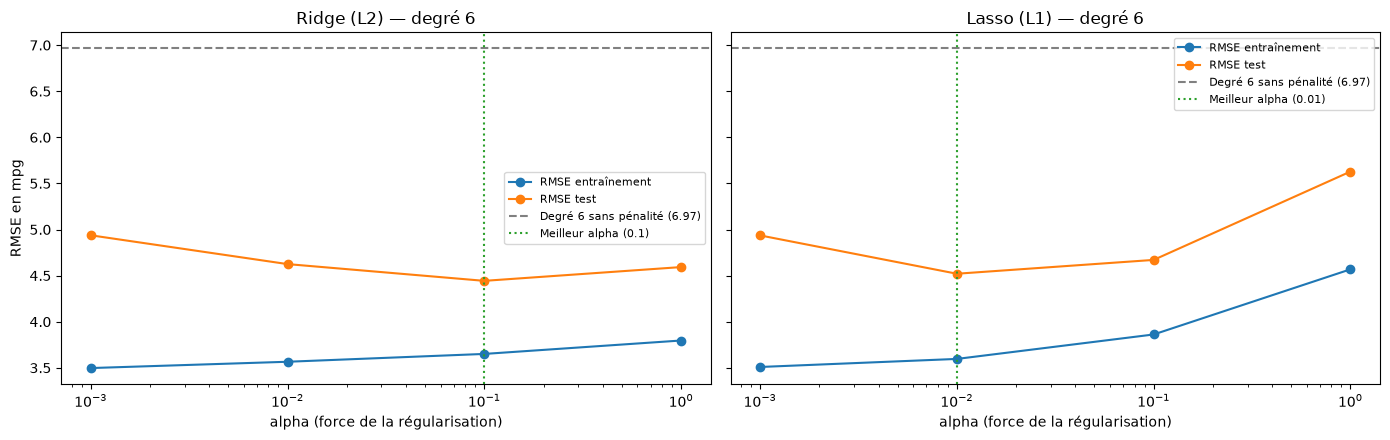

In [10]:
# Le point de depart : le modele de degre 6 sans penalite, celui qu'on repare.
_, _, rmse_sans_penalite = entraine(DEGRE)

penalites = {
    "Ridge (L2)": [Ridge(alpha=alpha) for alpha in alphas],
    "Lasso (L1)": [Lasso(alpha=alpha, max_iter=200_000) for alpha in alphas],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, (nom, modeles) in zip(axes, penalites.items()):
    erreurs_train, erreurs_test = [], []
    for modele in modeles:
        modele.fit(colonnes_train, y_train)
        erreurs_train.append(root_mean_squared_error(y_train, modele.predict(colonnes_train)))
        erreurs_test.append(root_mean_squared_error(y_test, modele.predict(colonnes_test)))

    meilleur_alpha = alphas[int(np.argmin(erreurs_test))]

    ax.plot(alphas, erreurs_train, marker="o", label="RMSE entraînement")
    ax.plot(alphas, erreurs_test, marker="o", label="RMSE test")
    ax.axhline(rmse_sans_penalite, color="grey", linestyle="--",
               label=f"Degré {DEGRE} sans pénalité ({rmse_sans_penalite:.2f})")
    ax.axvline(meilleur_alpha, color="tab:green", linestyle=":",
               label=f"Meilleur alpha ({meilleur_alpha})")
    ax.set_xscale("log")
    ax.set_xlabel("alpha (force de la régularisation)")
    ax.set_title(f"{nom} — degré {DEGRE}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("RMSE en mpg")
plt.tight_layout()
plt.show()

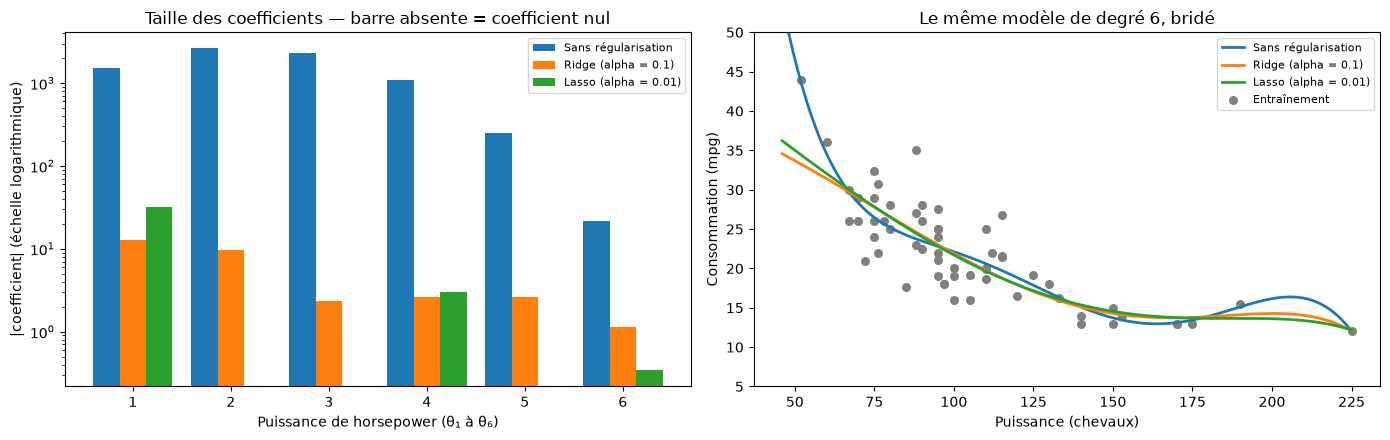

In [11]:
comparaison = {
    "Sans régularisation": LinearRegression(),
    "Ridge (alpha = 0.1)": Ridge(alpha=0.1),
    "Lasso (alpha = 0.01)": Lasso(alpha=0.01, max_iter=200_000),
}
colonnes_grille = colonnes_polynomiales(grille["horsepower"], DEGRE)

fig, (ax_coefs, ax_courbes) = plt.subplots(1, 2, figsize=(14, 4.5))

for decalage, (nom, modele) in enumerate(comparaison.items()):
    modele.fit(colonnes_train, y_train)
    ax_coefs.bar(np.arange(1, DEGRE + 1) + 0.27 * (decalage - 1), np.abs(modele.coef_), width=0.27, label=nom)
    ax_courbes.plot(grille["horsepower"], modele.predict(colonnes_grille), linewidth=2, label=nom)

ax_coefs.set_yscale("log")
ax_coefs.set_xticks(np.arange(1, DEGRE + 1))
ax_coefs.set_xlabel("Puissance de horsepower (θ₁ à θ₆)")
ax_coefs.set_ylabel("|coefficient| (échelle logarithmique)")
ax_coefs.set_title("Taille des coefficients — barre absente = coefficient nul")
ax_coefs.legend(fontsize=8)

ax_courbes.scatter(X_train["horsepower"], y_train, s=30, color="grey", label="Entraînement")
ax_courbes.set_ylim(5, 50)
ax_courbes.set_xlabel("Puissance (chevaux)")
ax_courbes.set_ylabel("Consommation (mpg)")
ax_courbes.set_title("Le même modèle de degré 6, bridé")
ax_courbes.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Ce qu'on observe** : le modèle n'a pas changé — c'est toujours le degré 6, avec les mêmes
six colonnes — et pourtant il redevient utilisable.

Le premier graphique raconte la même histoire qu'à l'étape 3, mais sur le bouton de la
régularisation au lieu du degré :

- le RMSE d'**entraînement** (en bleu) ne fait que monter. C'est logique : plus on bride le
  modèle, moins il peut coller aux données qu'il a sous les yeux ;
- le RMSE de **test** (en orange) est d'emblée très loin sous la ligne grise, qui rappelle
  d'où l'on part : 6,97 mpg sans pénalité. Il descend encore, atteint un creux, puis
  remonte. Le bon `alpha` est à ce creux, exactement comme le bon degré était au creux de la
  courbe de l'étape 3 ;
- **Ridge et Lasso ne se dégradent pas au même rythme.** Ridge reste bon sur toute la
  plage : de 0,01 à 1, son erreur de test tient entre 4,44 et 4,63. Lasso, lui, décroche
  après son creux et finit à 5,63 — en annulant des coefficients, il retire vraiment des
  colonnes au modèle, alors que Ridge se contente de les réduire.

- **Ridge** (α = 0,1) fait tomber l'erreur de test de 6,97 à **4,44 mpg**, soit un peu mieux
  que le degré 2 laissé libre (4,60). Le plus grand coefficient passe de 2 620 à 12,9 :
  aucun n'est annulé, tous sont tirés vers zéro. Sur le graphique de droite, la courbe
  bleue s'envole hors du cadre à gauche et forme une bosse vers 200 chevaux, alors que les
  deux courbes régularisées restent lisses.
- **Lasso** descend à 4,52 mpg en **annulant 3 coefficients sur 6**. Il ne garde que quelques puissances et fait donc, tout seul, une
  sélection de variables. C'est l'intérêt de L1 quand on a beaucoup de colonnes et qu'on
  ignore lesquelles servent.
- **Trop de régularisation fait sous-apprendre** : à α = 1, Lasso remonte à 5,63 mpg et son
  erreur d'entraînement repart vers le haut (4,57). On est retombé dans l'underfitting, par
  l'autre côté.

`alpha` est donc un réglage à choisir, exactement comme le degré : on en essaie plusieurs, et
on garde celui qui donne la plus petite erreur de test.

**À retenir pour le débriefing** :

- Un score sur les données d'entraînement ne prouve rien. Il faut **deux** erreurs : une sur
  l'entraînement, une sur des données que le modèle n'a jamais vues.
- Deux erreurs élevées et proches : **underfitting**, le modèle est trop simple. Une erreur
  d'entraînement basse et une erreur de test qui remonte : **overfitting**, le modèle
  mémorise. Entre les deux se trouve le bon compromis, dit **biais-variance**.
- La **régularisation** est une alternative à la simplification : on garde le modèle
  complexe, mais on pénalise la taille de ses coefficients. **Ridge** les réduit, **Lasso**
  peut les annuler et sélectionne ainsi des variables. Trop forte, elle fait sous-apprendre.
- Ces pièges ne dépendent pas de l'algorithme : montrés ici sur une régression linéaire, on
  les retrouvera sur la régression logistique du Titanic et sur les méthodes ensemblistes du
  chapitre 04.

Les notebooks suivants reviennent au Titanic, pour traiter ce qu'on a volontairement laissé
de côté jusqu'ici : les valeurs manquantes (notebook 03), puis la création de variables
(notebook 04).